In [1]:
from skimage.io import imread

im = imread('/home/bnorthan/images/tnia-python-images/imagesc/2026_03_18_stardist_cellcast/green.tif')

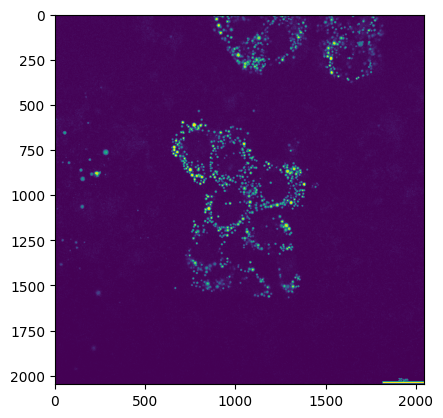

In [2]:
import matplotlib.pyplot as plt
plt.imshow(im)

In [3]:
from stardist.models import StarDist2D

model = StarDist2D.from_pretrained('2D_versatile_fluo')


2026-03-28 20:40:44.395413: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-28 20:40:44.686894: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-28 20:40:44.834578: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-28 20:40:44.836068: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-28 20:40:45.087394: I tensorflow/core/platform/cpu_feature_gua

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


2026-03-28 20:40:49.185771: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-28 20:40:49.637298: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-28 20:40:49.638104: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [4]:
from csbdeep.utils import normalize

In [5]:
im_normalized = normalize(im, 1, 99.8)  # normalizes using 1st and 99.8th percentiles

labels, details = model.predict_instances(
                im_normalized,
                prob_thresh=0.5,
                nms_thresh=0.3,
            )
            

I0000 00:00:1774744851.891882  251267 service.cc:145] XLA service 0x7395dc006030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774744851.891916  251267 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2026-03-28 20:40:51.946876: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-28 20:40:52.102231: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
2026-03-28 20:40:52.102231: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
2026-03-28 20:40:56.226206: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.20GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be perform

Text(0.5, 1.0, 'segmentation')

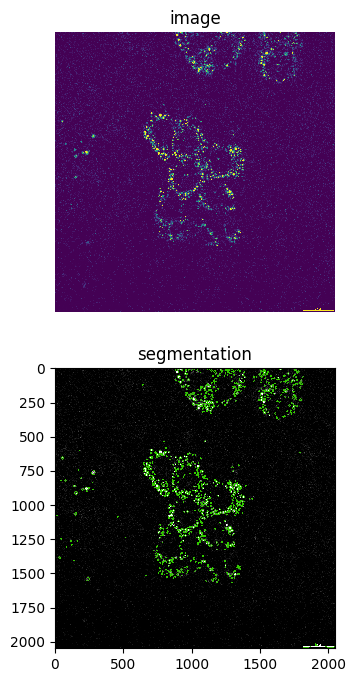

In [6]:
import matplotlib.pyplot as plt
from tnia.plotting.plt_helper import mask_outline_overlay
fig, axes = plt.subplots(2, 1, figsize=(4*3, 8))

axes[0].imshow(im)
axes[0].set_title(f'image')
axes[0].axis('off')

color = [50, 200, 0]

axes[1].imshow(mask_outline_overlay(im, labels, color=color, thickness=3))
axes[1].set_title(f'segmentation')




In [7]:
import cellcast.models.stardist_2d as sd

# run stardist inference and produce instance segmentations
cellcast_labels = sd.predict_versatile_fluo(im, prob_threshold=0.5, nms_threshold=0.3, gpu=True)

In [8]:
help(sd)

Help on module stardist_2d:

NAME
    stardist_2d

FUNCTIONS
    predict_versatile_fluo(data, pmin=None, pmax=None, prob_threshold=None, nms_threshold=None, gpu=None)
        Predict instance segmentation labels with the StarDist2D versatile fluo
        model.
        
        Performs model inference with the StarDist2D versatile fluo model, returning
        instance segmentations of star-convex shapes.
        
        Args:
            data: The input 2D image.
            pmin: The minimum percentage to linear percentile normalize the input
                image. If `None`, then `pmin = 1.0`.
            pmax: The maximum percentage to linear percentile normalize the input
                image. If `None`, then `pmax = 99.8`.
            prob_threshold: The object/polygon probability threshold. If `None`,
                then `prob_threshold == 0.479071463157368`.
            nms_threshold: The non-maximum suppression (NMS) threshold. If `None`,
                then `nms_threshol

In [16]:
help(sd.predict_versatile_fluo)

Help on built-in function predict_versatile_fluo:

predict_versatile_fluo(data, pmin=None, pmax=None, prob_threshold=None, nms_threshold=None, gpu=None)
    Predict instance segmentation labels with the StarDist2D versatile fluo
    model.
    
    Performs model inference with the StarDist2D versatile fluo model, returning
    instance segmentations of star-convex shapes.
    
    Args:
        data: The input 2D image.
        pmin: The minimum percentage to linear percentile normalize the input
            image. If `None`, then `pmin = 1.0`.
        pmax: The maximum percentage to linear percentile normalize the input
            image. If `None`, then `pmax = 99.8`.
        prob_threshold: The object/polygon probability threshold. If `None`,
            then `prob_threshold == 0.479071463157368`.
        nms_threshold: The non-maximum suppression (NMS) threshold. If `None`,
            then `nms_threshold == 0.3`.
        gpu: If `True`, GPU computation is used with the `Wgpu` bac

In [17]:
import napari
viewer = napari.Viewer()
viewer.add_image(im, name='image')
viewer.add_labels(labels, name='labels')
viewer.add_labels(cellcast_labels, name='cellcast_labels')

<Labels layer 'cellcast_labels' at 0x7062dc14d910>

In [18]:
# Compare the two label images
import numpy as np

# Count pixels that are different (where label indices differ)
different_pixels = np.sum(labels != cellcast_labels)
total_pixels = labels.size

# Calculate percentage
percentage_different = (different_pixels / total_pixels) * 100

print(f"Total pixels: {total_pixels}")
print(f"Different pixels: {different_pixels}")
print(f"Percentage different: {percentage_different:.2f}%")

# Also show some basic stats about each segmentation
print(f"\nStarDist labels - Number of objects: {labels.max()}")
print(f"CellCast labels - Number of objects: {cellcast_labels.max()}")


Total pixels: 4194304
Different pixels: 109669
Percentage different: 2.61%

StarDist labels - Number of objects: 1007
CellCast labels - Number of objects: 1009


In [21]:
help(sd.predict_versatile_fluo)

Help on built-in function predict_versatile_fluo:

predict_versatile_fluo(data, pmin=None, pmax=None, prob_threshold=None, nms_threshold=None, gpu=None)
    Predict instance segmentation labels with the StarDist2D versatile fluo
    model.
    
    Performs model inference with the StarDist2D versatile fluo model, returning
    instance segmentations of star-convex shapes.
    
    Args:
        data: The input 2D image.
        pmin: The minimum percentage to linear percentile normalize the input
            image. If `None`, then `pmin = 1.0`.
        pmax: The maximum percentage to linear percentile normalize the input
            image. If `None`, then `pmax = 99.8`.
        prob_threshold: The object/polygon probability threshold. If `None`,
            then `prob_threshold == 0.479071463157368`.
        nms_threshold: The non-maximum suppression (NMS) threshold. If `None`,
            then `nms_threshold == 0.3`.
        gpu: If `True`, GPU computation is used with the `Wgpu` bac